In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

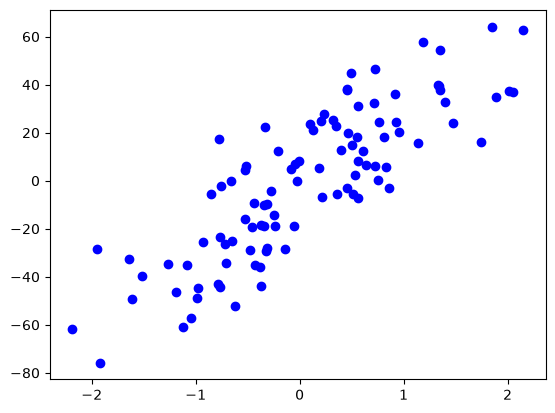

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)
plt.scatter(X, y, color='blue', label='Data points')

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [4]:
lr = LinearRegression()

lr.fit(X_train, y_train)
print(lr.coef_)
print(lr.intercept_)

[27.15099832]
-1.037344336263906


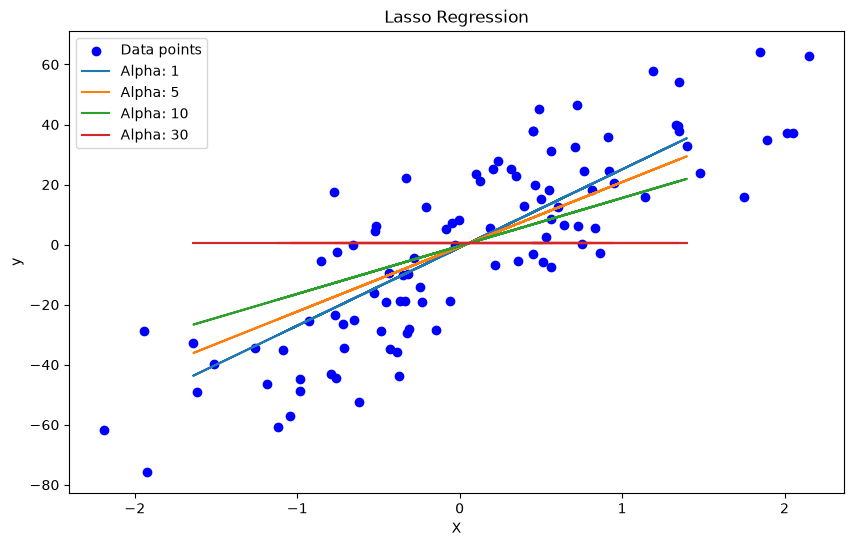

In [5]:
alphas = [1, 5, 10, 30]
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')

for i in alphas:
	lasso = Lasso(alpha=i)
	lasso.fit(X_train, y_train)
	plt.plot(X_test, lasso.predict(X_test), label=f'Alpha: {i}')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Lasso Regression')
plt.legend()

### Polynomial Regression with Lasso Regularization:

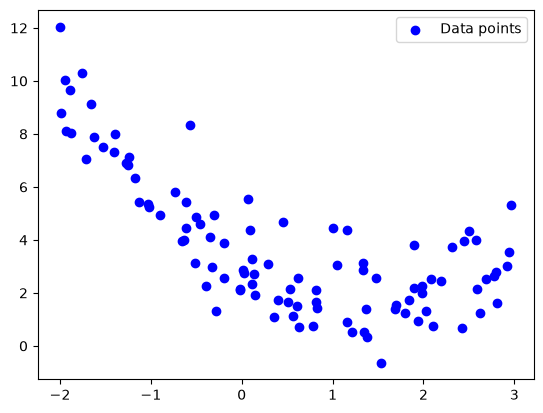

In [6]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1**2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2, color='blue', label='Data points')
plt.legend()

In [7]:
scaler = StandardScaler()
x1_scaled = scaler.fit_transform(x1.reshape(-1, 1) if x1.ndim == 1 else x1)

In [8]:
def get_lasso_predictions(x1, x2, alpha):
    model = Pipeline([
        ('poly_features', PolynomialFeatures(degree=16, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lasso_reg', Lasso(alpha=alpha, max_iter=10000))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

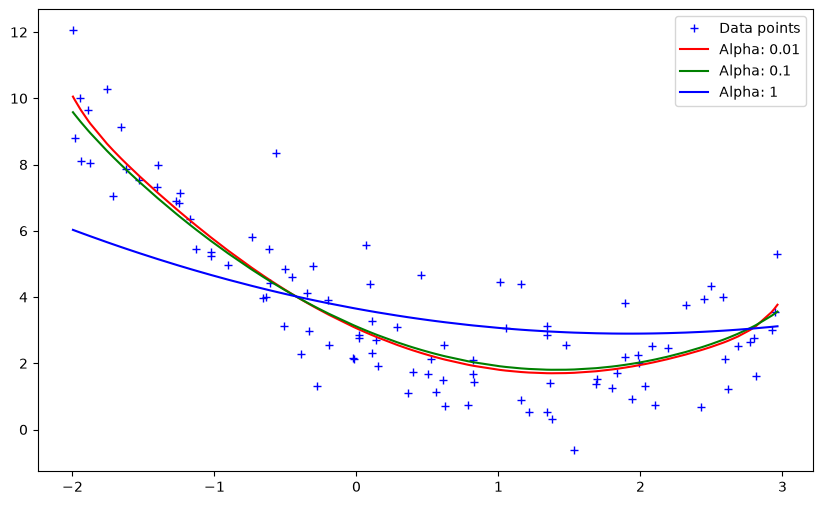

In [9]:
alphas = [0.01, 0.1, 1]
cs = ['red', 'green', 'blue']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Data points')

for alpha, c in zip(alphas, cs):
    y_pred = get_lasso_predictions(x1_scaled, x2, alpha)
    sort_idx = np.argsort(x1[:, 0])
    plt.plot(x1[sort_idx], y_pred[sort_idx], c, label=f'Alpha: {alpha}')

plt.legend()